## 전처리

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

In [110]:
df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv")
test_df = df.copy()

In [111]:
test_df.head().T

,0,1,2,3,4
Unnamed: 0,0,1,2,3,4
id,36121,36647,38663,38833,39282
source,city scrape,city scrape,city scrape,city scrape,city scrape
name,Lg Rm in Historic Prospect Heights,"1 Bedroom & your own Bathroom, Elevator Apartment",Luxury Brownstone in Boerum Hill,Spectacular West Harlem Garden Apt,“Work-from-home” from OUR home.
description,Cozy space share in the heart of a great neigh...,Private bedroom with your own bathroom in a 2 ...,"Beautiful, large home in great hipster neighbo...",This is a very large and unique space. An inc...,*Monthly Discount will automatically apply <br...
...,...,...,...,...,...
calculated_host_listings_count,1,1,1,1,2
calculated_host_listings_count_entire_homes,0,0,0,1,0
calculated_host_listings_count_private_rooms,1,1,1,0,2
calculated_host_listings_count_shared_rooms,0,0,0,0,0


In [112]:
test_df[test_df['host_is_superhost'].isna()]

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
257,401,333323,city scrape,Cozy bedroom near Times Square,1 bedroom in a 3 bedroom apartment centrally l...,Hell's Kitchen is a central vibrant neighborho...,1698391,Patrick,2012-02-04,"New York, NY",...,4.84,4.94,4.71,NaN,f,3,1,2,0,1.48
405,668,783202,city scrape,Charming First Floor Village Apt off Bleecker,DO NOT REQUEST A BOOKING TIL WE CHAT! SCROLL ...,This is Greenwich Village! The best neighborh...,4129805,Evelyn,2012-11-12,"New York, NY",...,4.80,4.98,4.72,Exempt,f,5,5,0,0,2.69
431,715,786685,city scrape,Historic Brownstone dwelling gorgeous garden,"Beautifully spacious rooms with huge, secure w...","This is a wonderful, vibrant neighborhood with...",4147380,Lauren,2012-11-14,"New York, NY",...,4.96,4.76,4.80,NaN,f,1,1,0,0,1.57
518,873,1042806,city scrape,My Other Little Guestroom,Warm and Cozy newly renovated bedroom in a fam...,Flushing Queens is a very safe and ethnically ...,2680820,Linda,2012-06-19,"New York, NY",...,4.89,4.61,4.81,OSE-STRREG-0000124,f,1,0,1,0,2.87
539,912,1411811,city scrape,"Charming Parlor Apt by Bleecker, Old World Vil...",PLS BE CONSIDERATE! Your request blocks my ca...,This is Greenwich Village! The best neighborh...,4129805,Evelyn,2012-11-12,"New York, NY",...,4.85,4.97,4.78,Exempt,f,5,5,0,0,2.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22040,37160,1359702695327440866,city scrape,Large Modern Bedroom 1-B,You are looking at a gorgeous large size bedro...,NaN,371046050,Daniela,2020-10-07,NaN,...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
22041,37161,1359754329005822690,city scrape,spacious 3 bedrooms in the city,This stylish place to stay is perfect for grou...,NaN,257606572,Daniel,2019-04-23,"New York, NY",...,NaN,NaN,NaN,NaN,t,2,2,0,0,NaN
22157,37278,1364579260115677851,city scrape,89-2R 1BR/1Bath on the UES,Embark on an unforgettable journey into the he...,Conveniently located in NYC's peaceful Upper E...,29468219,Pinhas,2015-03-16,"New York, NY",...,NaN,NaN,NaN,NaN,f,14,14,0,0,NaN
22282,37408,1365681782045610391,city scrape,Private NYC Bedroom,You'll have a great time at this comfortable p...,NaN,314462294,Michelle,2019-12-04,"New York, NY",...,NaN,NaN,NaN,NaN,f,8,2,6,0,NaN


In [113]:
test_df.columns

Index(['Unnamed: 0', 'id', 'source', 'name', 'description',
       'neighborhood_overview', 'host_id', 'host_name', 'host_since',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
     

In [114]:
test_df['license'].head()

0                   NaN
1                   NaN
2    OSE-STRREG-0001784
3    OSE-STRREG-0000476
4    OSE-STRREG-0001150
Name: license, dtype: str

In [115]:
test_df['price'].unique()

<StringArray>
[  '$200.00',    '$82.00',   '$765.00',   '$139.00',   '$130.00',    '$96.00',
    '$59.00',    '$67.00',   '$195.00',   '$290.00',
 ...
 '$1,033.00', '$1,278.00',   '$689.00', '$1,299.00', '$1,401.00',   '$852.00',
 '$1,239.00',   '$872.00',    '$16.00',    '$14.00']
Length: 1022, dtype: str

In [116]:
# 일단 가격부터 전처리
test_df['price'] = (
    test_df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [117]:
test_df['price'].head(10)

0    200.0
1     82.0
2    765.0
3    139.0
4    130.0
5    139.0
6     96.0
7     59.0
8     67.0
9    195.0
Name: price, dtype: float64

In [118]:
test_df['price'].isna().sum()

np.int64(0)

In [119]:
test_df['price'].describe()

count    22308.000000
mean       213.835216
std        427.599435
min          7.000000
25%         85.000000
50%        140.000000
75%        240.000000
max      20000.000000
Name: price, dtype: float64

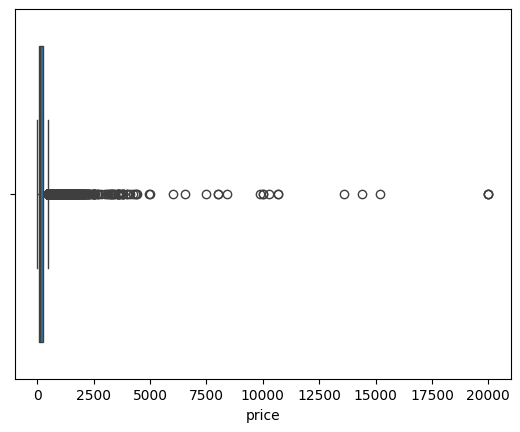

In [120]:
sns.boxplot(x=test_df['price'])
plt.show()

In [121]:
# 20000만 이하 컬럼만 남김
test_df = test_df[test_df['price'] < 20000]

In [122]:
test_df['price'].describe()

count    22305.000000
mean       211.173997
std        360.833902
min          7.000000
25%         85.000000
50%        140.000000
75%        240.000000
max      15200.000000
Name: price, dtype: float64

# price컬럼이랑 다른컬럼들간의 상관계수 알아보기

In [123]:
# 51번 컬럼 확인(12개월 리뷰 수)
print(test_df['number_of_reviews_ltm'].unique())
test_df['number_of_reviews_ltm'].head()

[   0   42   12    3    5   36    1    2   68    4   56   30   24   15
    6   21   59   11   31   16   67    7   27   14    9   33   25    8
   17   41   35   34   61   28   40   51   19   39   20   55   22   32
   38   29   62   43   69   26   60   18   45   81   13   54   37   77
   47   46   10   57   95   50   63   90   49   44   65   76   48   73
   53   84   72   52   23   74   64   66   58  173   79   94   93   85
   71   70   96   82  100   78  139   75  290  122  167  105   86  136
  103  117  148  126  124  101  365   89  198  619   80  169  295   83
  147  102   91  110 1290   97  418   87   92   98  491  254  128  138
  285  116  569  369  127  203  181  163  123  108  178  107  184 1784
  330  155   88  262  165  142  114  655  281  280  172  144  111  214
  166  151  113  132  135  228  119  620  306  121  143  261  511  381
  230  161]


0     0
1     0
2     0
3    42
4    12
Name: number_of_reviews_ltm, dtype: int64

In [124]:
test_df['number_of_reviews_ltm'].isna().sum()

np.int64(0)

- 정수형에 결측도 없고 데이터 깔끔함 전처리 불필요 price랑 상관계수 분석 가능

In [125]:
test_df['number_of_reviews_ltm'].describe()

count    22305.000000
mean         6.137906
std         24.605696
min          0.000000
25%          0.000000
50%          0.000000
75%          3.000000
max       1784.000000
Name: number_of_reviews_ltm, dtype: float64

- ?? 왜 이상치가 있지....아 찾아보니 리뷰수는 통계적으로는 이상치여도 실제로 발생가능한 값으로 판단 음...(인기숙소 판단가능) 예) 리뷰 수, 판매량, 조회수

In [126]:
# 52번 컬럼 확인(30일 리뷰 수)
test_df['number_of_reviews_l30d'].describe()

count    22305.000000
mean         0.320959
std          1.876204
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        135.000000
Name: number_of_reviews_l30d, dtype: float64

- 음... 30일간 전체숙소중 75%가 리뷰가 없음... 전체적으로 int형에 데이터 깔끔 결측도 없음 이상치 없음 상관계수 분석 가능

- availability_eoy 변수는 연말 기준 예약 가능 일수를 의미하는 변수로 단기 수요 흐름 / 최근 급상승 숙소 탐지 가능 값이다. 본 분석에서는 가격(price)과 직접적인 관계를 해석하기 어렵다고 판단하여 분석 변수에서 제외

In [127]:
# 54번 컬럼 확인(작년 리뷰 수)
test_df['number_of_reviews_ly'].describe()

count    22305.000000
mean         5.915176
std         24.118033
min          0.000000
25%          0.000000
50%          0.000000
75%          3.000000
max       1797.000000
Name: number_of_reviews_ly, dtype: float64

- 작년 리뷰 수 확인 결과 최근 12개월 리뷰수랑 별 차이 안남 13? 그래서 둘다 비슷한 분포를 뛸거같아 상관계수 분석에서 제외(ltm사용)

In [128]:
# 55번 컬럼 확인(365일 기준 점유율)
test_df['estimated_occupancy_l365d'].describe()

count    22305.000000
mean        71.572338
std         96.625362
min          0.000000
25%          0.000000
50%          0.000000
75%        120.000000
max        255.000000
Name: estimated_occupancy_l365d, dtype: float64

max값 255일 이상치는 없는거 같음 365일 기준이면 255일 합당함(결측도 없어 분석 가능)

In [129]:
# 56번 컬럼 확인(연간 예상 매출)
test_df['estimated_revenue_l365d'].describe()

count    2.230500e+04
mean     1.190354e+04
std      2.418816e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.650000e+04
max      1.020050e+06
Name: estimated_revenue_l365d, dtype: float64

- 아 어렵네...연간 예상 매출 price의 파생컬럼인거 같은데 매출이면 흠.... price기준 상관계수 분석이니 제외해도 될 듯?

In [130]:
# 57번 컬럼 확인(첫 리뷰 날짜)
test_df['first_review'].head()

0    2010-12-11
1    2010-10-04
2    2012-07-09
3    2010-08-28
4    2010-08-02
Name: first_review, dtype: str

In [131]:
test_df['first_review'].isna().sum()

np.int64(6795)

- 일단 날짜 컬럼이 str형식으로 되어 있다 결측(6795) 때문인거 같다. 상관계수 분석에서 제외(수치형 자료가 아님 dt) 58번 컬럼(최근리뷰날짜)도 해당

In [132]:
# 59번 컬럼 확인(평점)전반적
test_df['review_scores_rating'].describe()

count    15510.000000
mean         4.724384
std          0.457137
min          1.000000
25%          4.662500
50%          4.850000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

# 바로 상관계수 분석 해도 될듯... 생각해보니 정리가 되있네...

53,54,56,57,58 제외(license도 제외 텍스트형이고 price랑 연관없어 보임)

In [133]:
# 51컬럼
test_df['price'].corr(test_df['number_of_reviews_ltm'])

np.float64(-0.022315217739780912)

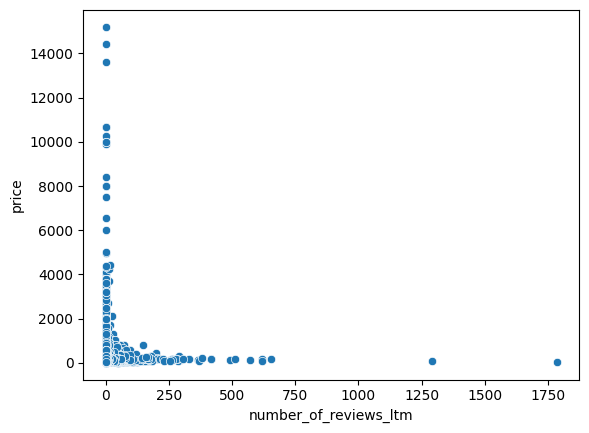

In [134]:
sns.scatterplot(x=test_df['number_of_reviews_ltm'], y=test_df['price'])
plt.show()

In [135]:
# 52컬럼
test_df['price'].corr(test_df['number_of_reviews_l30d'])

np.float64(-0.014649277003503155)

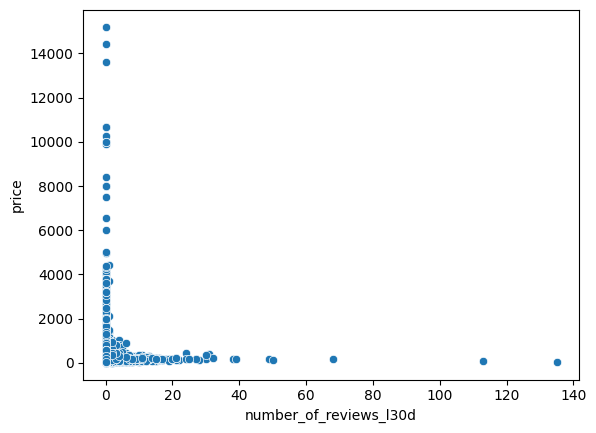

In [136]:
sns.scatterplot(x=test_df['number_of_reviews_l30d'], y=test_df['price'])
plt.show()

In [137]:
# 55 컬럼
test_df['price'].corr(test_df['estimated_occupancy_l365d'])

np.float64(-0.09209115887362244)

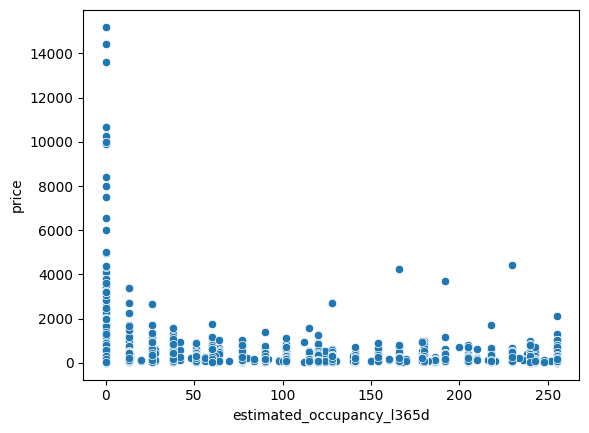

In [138]:
sns.scatterplot(x=test_df['estimated_occupancy_l365d'], y=test_df['price'])
plt.show()

In [139]:
# 59 컬럼
test_df['price'].corr(test_df['review_scores_rating'])

np.float64(0.04395728738180065)

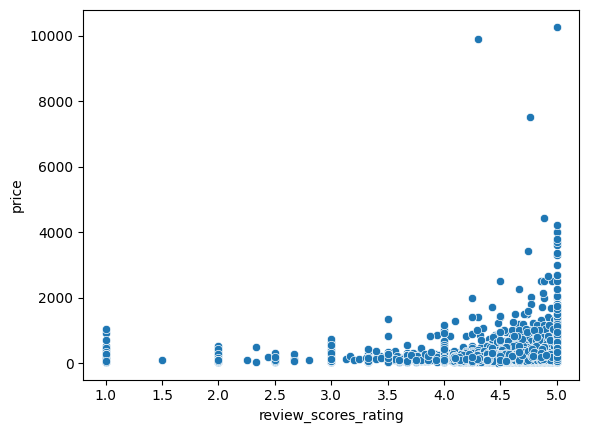

In [140]:
sns.scatterplot(x=test_df['review_scores_rating'], y=test_df['price'])
plt.show()

In [141]:
# 60 컬럼
test_df['price'].corr(test_df['review_scores_accuracy'])

np.float64(0.03470980673763494)

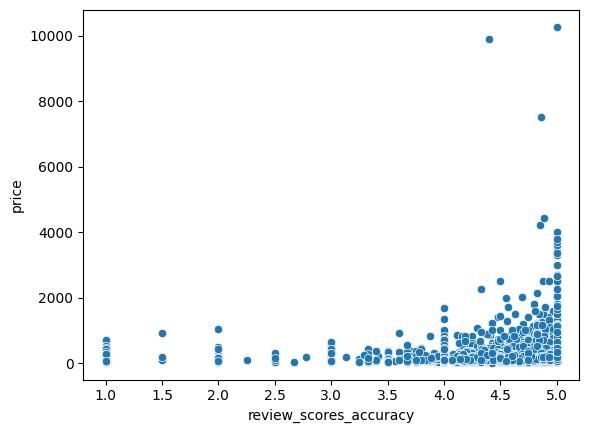

In [142]:
sns.scatterplot(x=test_df['review_scores_accuracy'], y=test_df['price'])
plt.show()

In [143]:
# 61 컬럼
test_df['price'].corr(test_df['review_scores_cleanliness'])

np.float64(0.05582800182833005)

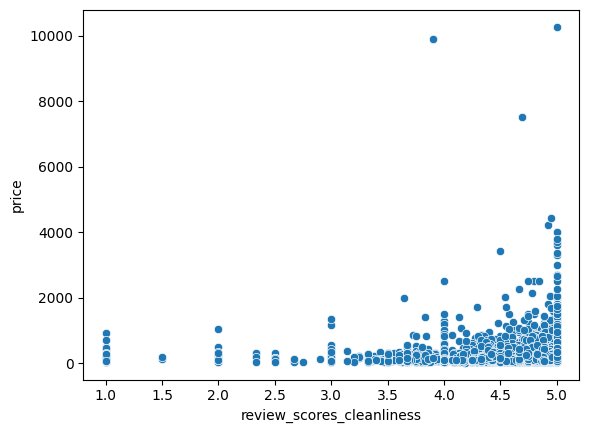

In [144]:
sns.scatterplot(x=test_df['review_scores_cleanliness'], y=test_df['price'])
plt.show()

In [145]:
# 62 컬럼
test_df['price'].corr(test_df['review_scores_checkin'])

np.float64(0.02229354153866021)

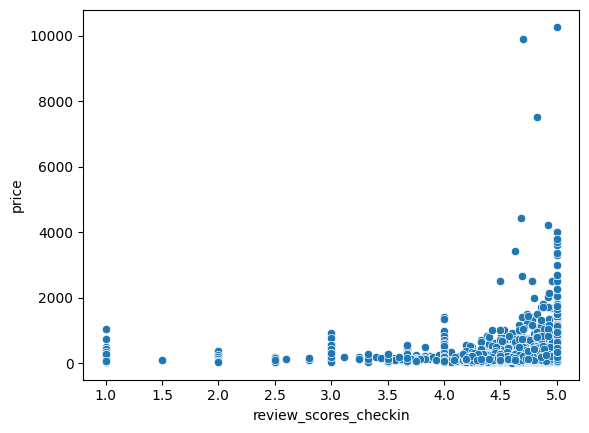

In [146]:
sns.scatterplot(x=test_df['review_scores_checkin'], y=test_df['price'])
plt.show()

In [147]:
# 63 컬럼
test_df['price'].corr(test_df['review_scores_communication'])

np.float64(0.02376877847187377)

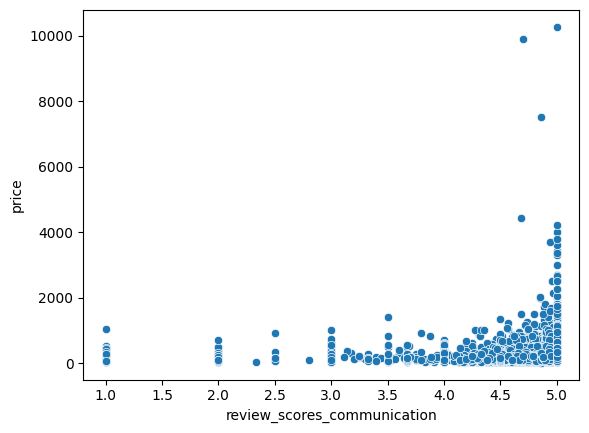

In [148]:
sns.scatterplot(x=test_df['review_scores_communication'], y=test_df['price'])
plt.show()

In [149]:
# 64 컬럼
test_df['price'].corr(test_df['review_scores_location'])

np.float64(0.0858486200669148)

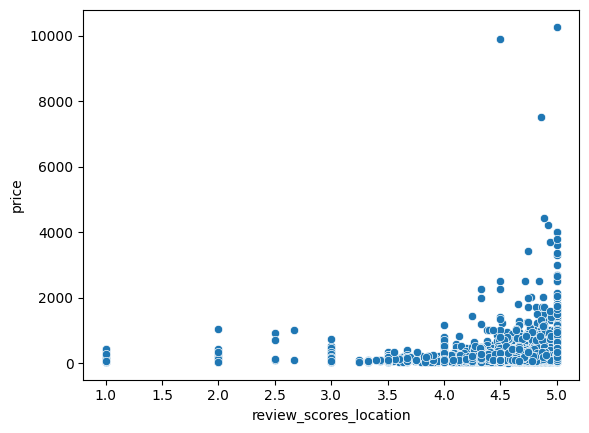

In [150]:
sns.scatterplot(x=test_df['review_scores_location'], y=test_df['price'])
plt.show()

In [151]:
# 65 컬럼
test_df['price'].corr(test_df['review_scores_value'])

np.float64(0.012482731593204725)

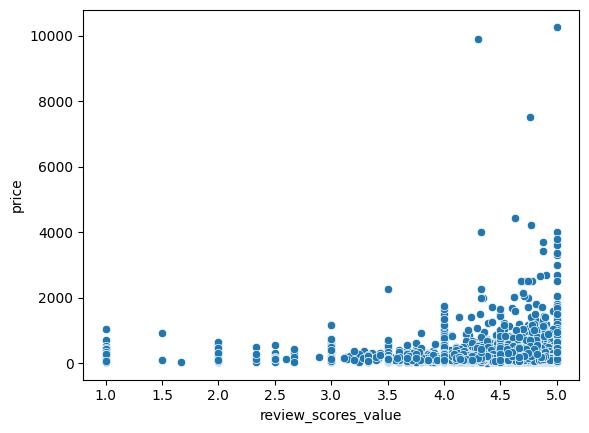

In [152]:
sns.scatterplot(x=test_df['review_scores_value'], y=test_df['price'])
plt.show()

In [153]:
# 67번 컬럼 true/flase 바꿔줘야 상관관계 분석 가능
test_df['instant_bookable'] = test_df['instant_bookable'].map({'t':1,'f':0})

In [154]:
test_df['instant_bookable']

0        0
1        0
2        0
3        0
4        0
        ..
22303    0
22304    0
22305    0
22306    1
22307    0
Name: instant_bookable, Length: 22305, dtype: int64

In [155]:
# 67 컬럼
test_df['price'].corr(test_df['instant_bookable'])

np.float64(0.11605801994981908)

<Axes: xlabel='instant_bookable', ylabel='price'>

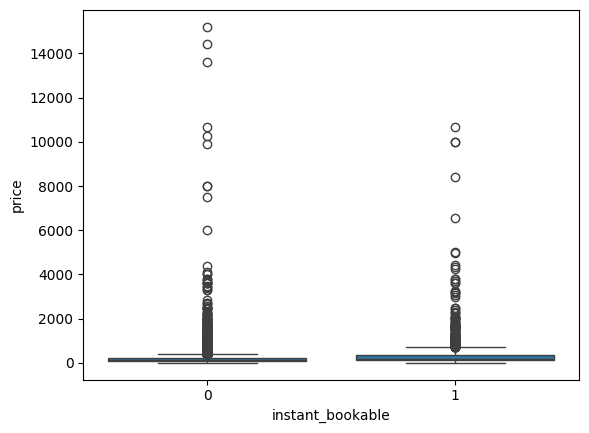

In [156]:
# 이진변수 true/false라 박스플롯이 더 좋다고 판단
sns.boxplot(x=test_df['instant_bookable'], y=test_df['price'])

In [157]:
# 68 컬럼
test_df['price'].corr(test_df['calculated_host_listings_count'])

np.float64(0.11511594423638581)

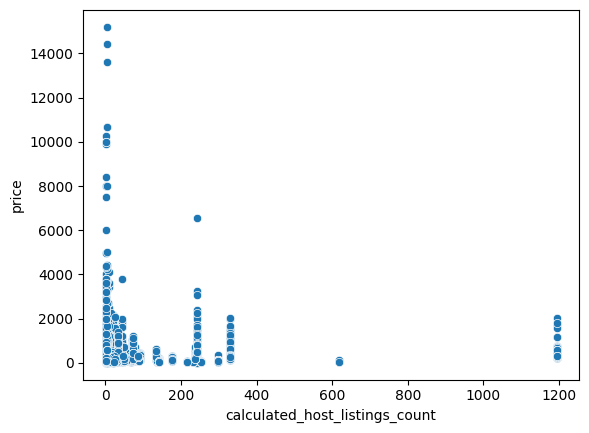

In [158]:
sns.scatterplot(x=test_df['calculated_host_listings_count'], y=test_df['price'])
plt.show()

In [159]:
# 69 컬럼
test_df['price'].corr(test_df['calculated_host_listings_count_entire_homes'])

np.float64(0.12459035439006307)

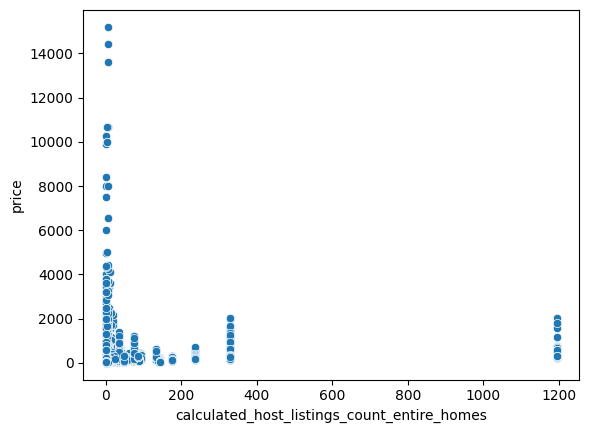

In [160]:
sns.scatterplot(x=test_df['calculated_host_listings_count_entire_homes'], y=test_df['price'])
plt.show()

In [161]:
# 70 컬럼
test_df['price'].corr(test_df['calculated_host_listings_count_private_rooms'])

np.float64(-0.0754551168637336)

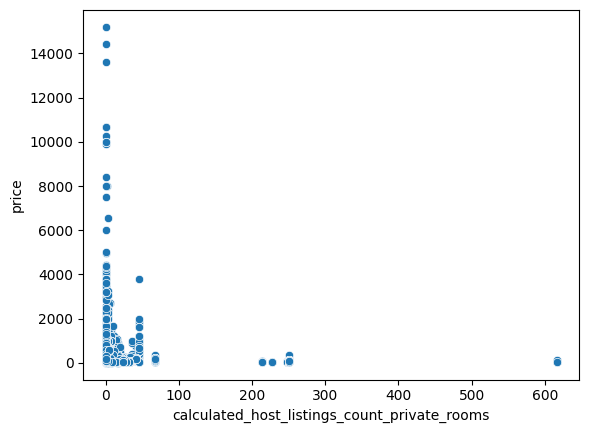

In [162]:
sns.scatterplot(x=test_df['calculated_host_listings_count_private_rooms'], y=test_df['price'])
plt.show()

In [163]:
# 71 컬럼
test_df['price'].corr(test_df['calculated_host_listings_count_shared_rooms'])

np.float64(-0.031944033456751314)

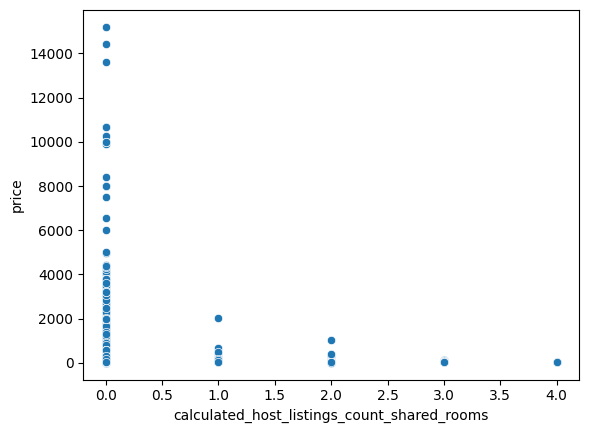

In [164]:
sns.scatterplot(x=test_df['calculated_host_listings_count_shared_rooms'], y=test_df['price'])
plt.show()

In [165]:
# 72 컬럼
test_df['price'].corr(test_df['reviews_per_month'])

np.float64(-0.0117642208289792)

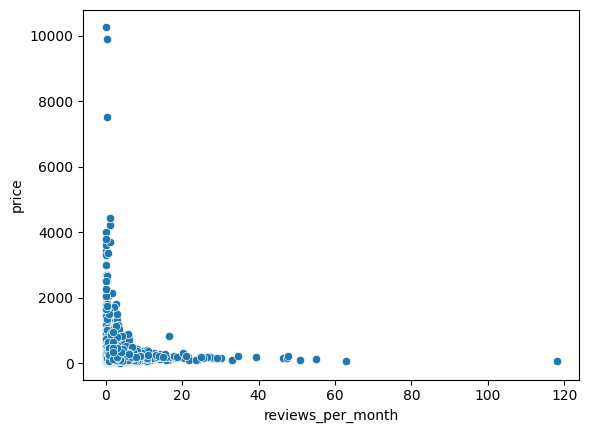

In [166]:
sns.scatterplot(x=test_df['reviews_per_month'], y=test_df['price'])
plt.show()

In [167]:
corr = test_df[['price',
'number_of_reviews_ltm',
'number_of_reviews_l30d',
'estimated_occupancy_l365d',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'instant_bookable',
'calculated_host_listings_count',
'calculated_host_listings_count_entire_homes',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month'
]].corr()['price'].sort_values(ascending=False)

corr

price                                           1.000000
calculated_host_listings_count_entire_homes     0.124590
instant_bookable                                0.116058
calculated_host_listings_count                  0.115116
review_scores_location                          0.085849
review_scores_cleanliness                       0.055828
review_scores_rating                            0.043957
review_scores_accuracy                          0.034710
review_scores_communication                     0.023769
review_scores_checkin                           0.022294
review_scores_value                             0.012483
reviews_per_month                              -0.011764
number_of_reviews_l30d                         -0.014649
number_of_reviews_ltm                          -0.022315
calculated_host_listings_count_shared_rooms    -0.031944
calculated_host_listings_count_private_rooms   -0.075455
estimated_occupancy_l365d                      -0.092091
Name: price, dtype: float64

In [168]:
type(corr)

pandas.Series

In [169]:
corr_heat = test_df[['price',
'number_of_reviews_ltm',
'number_of_reviews_l30d',
'estimated_occupancy_l365d',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'instant_bookable',
'calculated_host_listings_count',
'calculated_host_listings_count_entire_homes',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month'
]].corr()

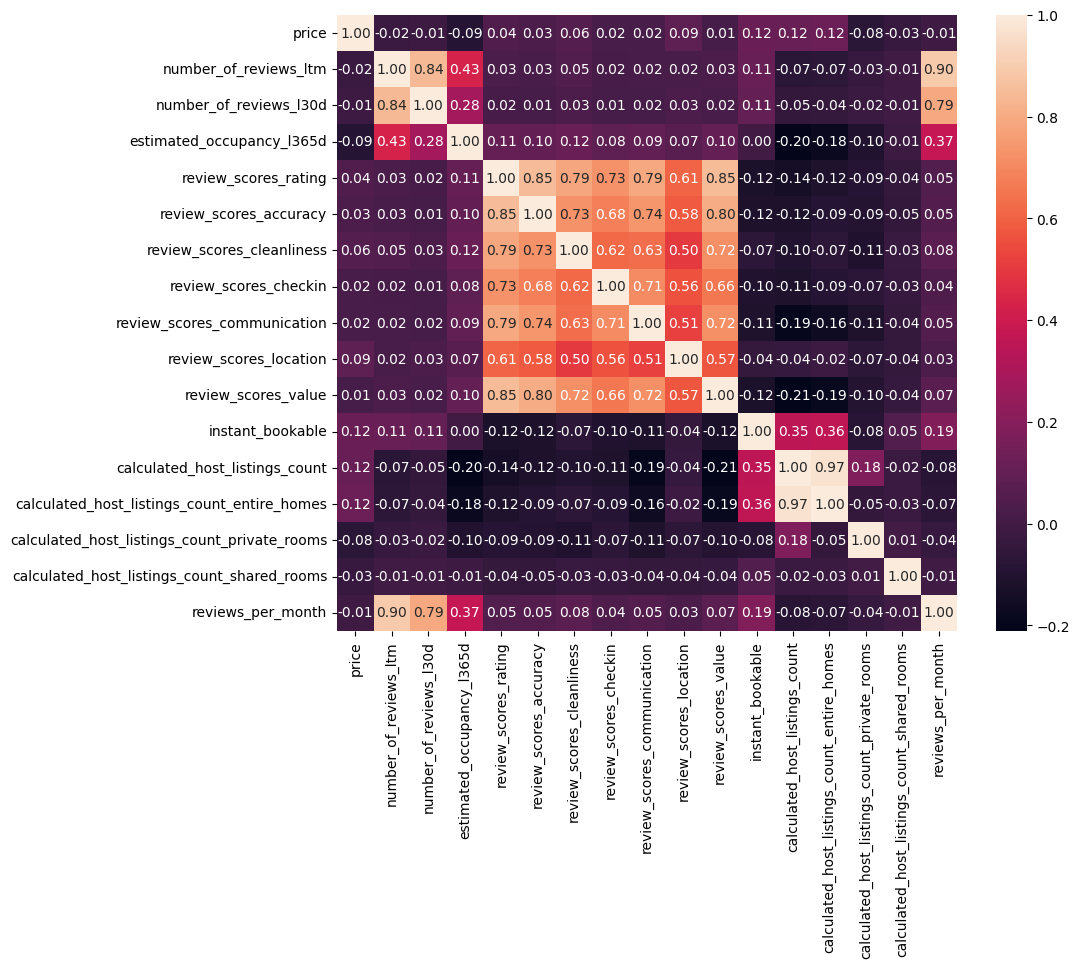

In [170]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_heat, annot=True, fmt='.2f')
plt.show()

In [171]:
# top 1
test_df[['price','calculated_host_listings_count_entire_homes']].corr().round(2)

,price,calculated_host_listings_count_entire_homes
price,1.00,0.12
calculated_host_listings_count_entire_homes,0.12,1.00


<Axes: xlabel='calculated_host_listings_count_entire_homes', ylabel='price'>

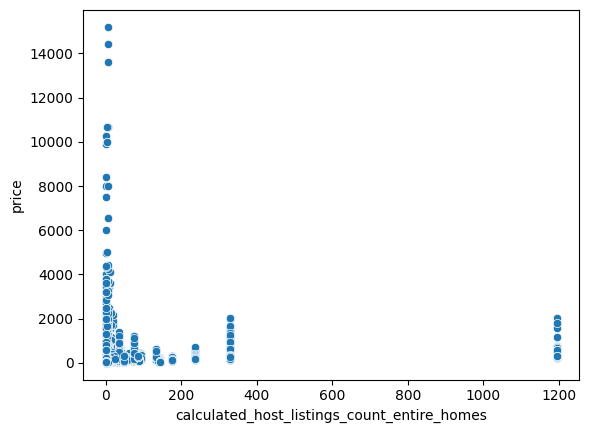

In [172]:
sns.scatterplot(x=test_df['calculated_host_listings_count_entire_homes'],y=test_df['price'])

- 51~72(제외컬럼 빼고)price와의 상관관계 분석 결과 대부분의 컬럼들이 0.1이하로 나타나 price 와의 직접적인 관계는 매우 약한 것으로 확인
그 중 calculated_host_listings_count_entire_homes가 그나마 0.124로 가장 높은데 호스트가 보유한 숙소 수가 많을수록 가격이 높은 경향이 보임
가격에 큰영향을 미치는 컬럼은 없음

In [173]:
test_df[['reviews_per_month']]

,reviews_per_month
0,0.05
1,0.58
2,0.28
3,1.36
4,1.54
...,...
22303,NaN
22304,NaN
22305,NaN
22306,NaN


In [174]:
test_df['reviews_per_month'].isna().sum()

np.int64(6795)

기존 데이터셋(test_df)의 72개 컬럼 중
분석에 필요한 37개 컬럼만 선택하여
새로운 DataFrame(df)을 생성

1. 1~7 컬럼별 의미 및 데이터 타입 확인
description
host_id
host_since
host_response_time
host_response_rate
host_acceptance_rate
host_is_superhost

# ============================================================
# 1 ~ 7 주요 컬럼 설명
# ============================================================
# • description                   : 숙소 설명
# • host_id                       : 호스트 고유 ID
# • host_since                  : 호스트 가입 일짜
# • host_response_time                       : 호스트 응답 시간
# • host_response_rate            : 호스트 응답률
# • host_acceptance_rate           : 예약 요청 수락률
# • host_is_superhost       : 슈퍼호스트 여부

In [202]:
selected_cols =[
'id',
'name',
'description',
'host_id',
'host_since',
'host_response_time',
'host_response_rate',
'host_acceptance_rate',
'host_is_superhost',
'neighbourhood_cleansed',
'neighbourhood_group_cleansed',
'latitude',
'longitude',
'property_type',
'room_type',
'accommodates',
'bedrooms',
'beds',
'amenities',
'price',
'availability_365',
'number_of_reviews',
'number_of_reviews_ltm',
'estimated_occupancy_l365d',
'estimated_revenue_l365d',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'calculated_host_listings_count',
'calculated_host_listings_count_entire_homes',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month']

In [203]:
df = test_df[selected_cols]
df2 = df.copy()

In [204]:
df2.shape

(22305, 37)

In [205]:
df2.columns

Index(['id', 'name', 'description', 'host_id', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds',
       'amenities', 'price', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month'],
      dtype='str')

In [206]:
df2[df2['description'].isna()].head()

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
5,39572,1 br in a 2 br apt (Midtown West),NaN,169927,2010-07-17,NaN,NaN,NaN,f,Hell's Kitchen,...,4.83,4.98,5.00,4.98,4.86,2,1,1,0,0.25
14,96471,"The Brooklyn Waverly, One Bedroom",NaN,116599,2010-05-01,NaN,NaN,NaN,f,Clinton Hill,...,4.82,4.82,5.00,4.91,4.73,3,1,2,0,0.07
19,42729,@HouseOnHenrySt - Private 2nd bedroom w/shared...,NaN,11481,2009-03-26,a few days or more,40%,17%,f,Carroll Gardens,...,4.81,4.71,4.73,4.58,4.64,4,1,3,0,1.25
30,45910,Beautiful Queens Brownstone! - 5BR,NaN,204539,2010-08-17,within a few hours,100%,11%,f,Ridgewood,...,4.36,4.82,5.00,4.82,4.55,10,8,2,0,0.08
32,45936,Couldn't Be Closer To Columbia Uni,NaN,867225,2011-07-25,within a day,100%,100%,t,Morningside Heights,...,4.48,4.87,4.87,4.89,4.63,2,0,2,0,0.78


In [207]:
df2['description'].isna().sum()

np.int64(405)

In [208]:
# 1번 전처리 결측값 unknown으로 대체
df2['description'] = df2['description'].fillna('unknown')

In [209]:
df2['description'].isna().sum()

np.int64(0)

In [210]:
df2[df2['description'] == 'unknown']

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
5,39572,1 br in a 2 br apt (Midtown West),unknown,169927,2010-07-17,NaN,NaN,NaN,f,Hell's Kitchen,...,4.83,4.98,5.00,4.98,4.86,2,1,1,0,0.25
14,96471,"The Brooklyn Waverly, One Bedroom",unknown,116599,2010-05-01,NaN,NaN,NaN,f,Clinton Hill,...,4.82,4.82,5.00,4.91,4.73,3,1,2,0,0.07
19,42729,@HouseOnHenrySt - Private 2nd bedroom w/shared...,unknown,11481,2009-03-26,a few days or more,40%,17%,f,Carroll Gardens,...,4.81,4.71,4.73,4.58,4.64,4,1,3,0,1.25
30,45910,Beautiful Queens Brownstone! - 5BR,unknown,204539,2010-08-17,within a few hours,100%,11%,f,Ridgewood,...,4.36,4.82,5.00,4.82,4.55,10,8,2,0,0.08
32,45936,Couldn't Be Closer To Columbia Uni,unknown,867225,2011-07-25,within a day,100%,100%,t,Morningside Heights,...,4.48,4.87,4.87,4.89,4.63,2,0,2,0,0.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22169,1356862958825673292,A cozy private room in Brooklyn by the park,unknown,96876878,2016-09-26,NaN,NaN,NaN,f,Brownsville,...,NaN,NaN,NaN,NaN,NaN,2,0,2,0,NaN
22174,1362407813755960846,Ultra Luxury Furnished Flat for work & leisure,unknown,25121302,2014-12-23,within a few hours,100%,NaN,f,Hell's Kitchen,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
22192,1357574158630690509,Sunny and quiet 3rd Floor 1-BR,unknown,358641758,2020-07-26,within a few hours,100%,0%,f,South Slope,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
22228,1358822659920606401,New/Private 1 BR | Brownstone,unknown,678480021,2025-02-12,NaN,NaN,NaN,f,Bedford-Stuyvesant,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN


In [211]:
df2['host_since'].isna().sum()

np.int64(20)

In [212]:
# 2번 전처리 결측값 unkonown으로 대체
df2['host_since'] = df2['host_since'].fillna('unknown')

In [213]:
df2['host_since'].isna().sum()

np.int64(0)

In [214]:
df2[df2['host_since'] == 'unknown']

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
229,302758,Sunny 1BR East Harlem Apartment,Two-room apartment in East Harlem. Close to su...,8605,unknown,NaN,NaN,NaN,f,East Harlem,...,3.58,4.83,4.75,3.83,4.17,1,1,0,0,0.08
1452,7037918,"Near LGA, Citifield, US Open Tennis","Comfortable, sunny, cozy bedroom in private ho...",36242220,unknown,NaN,NaN,NaN,f,East Elmhurst,...,4.76,4.91,4.93,4.87,4.76,1,0,1,0,1.97
2943,20193830,Family brownstone with backyard,"Located in Clinton Hill, a historic Brooklyn n...",1294005,unknown,NaN,NaN,NaN,t,Clinton Hill,...,4.90,4.99,4.98,4.96,4.88,1,1,0,0,1.24
3161,21802923,Private Bedroom with Private Entrance in Brook...,You will have a large bedroom with a private e...,72466752,unknown,NaN,NaN,NaN,f,Bushwick,...,4.52,4.78,4.80,4.85,4.65,1,0,1,0,0.61
6090,45189535,Private Room for Sleeping in Great Neighborhood,"Safe, quiet, private, NYC room available just ...",364960386,unknown,NaN,NaN,NaN,f,Upper West Side,...,5.00,5.00,4.92,4.96,4.92,1,0,1,0,0.49
6536,47009616,1 bedroom apartment near Staten Island ferry,This is a one bedroom apartment with a living ...,260396179,unknown,NaN,NaN,NaN,f,Tompkinsville,...,4.88,4.88,4.71,4.58,4.71,4,4,0,0,0.51
6568,46705156,2 Bedroom apartment in ENY Business District,Cozy 2BR APARTMENT with huge master BR and wal...,377484768,unknown,NaN,NaN,NaN,f,East New York,...,4.86,4.91,4.86,4.18,4.69,1,1,0,0,2.16
7354,49980221,2 bedroom apartment near Staten Island ferry,This is a two bedroom apartment near the State...,260396179,unknown,NaN,NaN,NaN,f,Tompkinsville,...,4.71,4.93,4.96,4.57,4.71,4,4,0,0,0.76
8307,53050810,Bedroom w/private bathroom in Unit2 in Greenpoint,"Greenpoint is a safe, convenient option for ex...",17888612,unknown,NaN,NaN,NaN,t,Greenpoint,...,4.82,4.94,4.99,4.95,4.93,1,0,1,0,4.30
11373,736139385311072356,Relaxing 1 Bedroom in Brooklyn,"Unwind in this cute, modern, 1 bedroom apartme...",35174210,unknown,NaN,NaN,NaN,t,Bay Ridge,...,5.00,5.00,5.00,5.00,4.83,2,2,0,0,0.32


In [215]:
df2['host_response_time'].value_counts()

host_response_time
within an hour        11642
within a few hours     3439
within a day           1957
a few days or more      874
Name: count, dtype: int64

In [216]:
# 3번 전처리 범주형 값들을 숫자형 4,3,2,1로 대체
mapping = {'within an hour': 4, 'within a few hours': 3, 'within a day': 2, 'a few days or more': 1}
df2['host_response_time'] = df2['host_response_time'].map(mapping)

In [217]:
df2['host_response_time'].head(20)

0     NaN
1     NaN
2     3.0
3     4.0
4     4.0
5     NaN
6     4.0
7     4.0
8     4.0
9     4.0
10    4.0
11    4.0
12    4.0
13    3.0
14    NaN
15    3.0
16    NaN
17    3.0
18    NaN
19    1.0
Name: host_response_time, dtype: float64

In [218]:
#2 그러고 결측값들은 unknown으로 대체
df2['host_response_time'] = df2['host_response_time'].fillna('unknown')
df2['host_response_time'].head()

0    unknown
1    unknown
2        3.0
3        4.0
4        4.0
Name: host_response_time, dtype: object

In [219]:
df2['host_response_rate'].head()

0     NaN
1     NaN
2    100%
3    100%
4    100%
Name: host_response_rate, dtype: str

In [220]:
df2['host_response_rate'].isna().sum()

np.int64(4393)

In [221]:
# 4번 전처리 일단은 %부분이 있어 문자열형이라 숫자형으로 바꿔줬음(내일 결측값 어떡해 할지 다시 상의 해봐야 할듯요 어렵네요...)보류
df2['host_response_rate'] = (df2['host_response_rate'].str.replace('%', '', regex=False).astype(float))

In [222]:
df2['host_response_rate'].head(10)

0      NaN
1      NaN
2    100.0
3    100.0
4    100.0
5      NaN
6    100.0
7    100.0
8    100.0
9    100.0
Name: host_response_rate, dtype: float64

In [223]:
df2.info()

<class 'pandas.DataFrame'>
Index: 22305 entries, 0 to 22307
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22305 non-null  int64  
 1   name                                          22305 non-null  str    
 2   description                                   22305 non-null  str    
 3   host_id                                       22305 non-null  int64  
 4   host_since                                    22305 non-null  str    
 5   host_response_time                            22305 non-null  object 
 6   host_response_rate                            17912 non-null  float64
 7   host_acceptance_rate                          18839 non-null  str    
 8   host_is_superhost                             21931 non-null  str    
 9   neighbourhood_cleansed                        22305 non-null  str    
 10  ne

In [224]:
df2['host_response_rate'].describe()

count    17912.000000
mean        93.041313
std         19.290560
min          0.000000
25%         99.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate, dtype: float64

In [225]:
df2['host_acceptance_rate'].head()

0     NaN
1    100%
2     40%
3     97%
4    100%
Name: host_acceptance_rate, dtype: str

In [226]:
df2['host_acceptance_rate'].isna().sum()

np.int64(3466)

In [227]:
df2['host_acceptance_rate'] = (df2['host_acceptance_rate'].str.replace('%', '', regex=False).astype(float))

In [228]:
df2['host_acceptance_rate'].describe()

count    18839.000000
mean        78.159722
std         27.946436
min          0.000000
25%         67.000000
50%         91.000000
75%        100.000000
max        100.000000
Name: host_acceptance_rate, dtype: float64

In [229]:
df2['host_is_superhost'].value_counts()

host_is_superhost
f    15796
t     6135
Name: count, dtype: int64

In [230]:
# 일단 슈퍼호스트 값을 f/t를 숫자형 1,0으로 바꿔주고(매핑)
df2['host_is_superhost'] = df2['host_is_superhost'].map({'t':1, 'f':0})

In [231]:
df2.loc[
    (df2["host_is_superhost"] == 1) & 
    (df2["host_acceptance_rate"].isna())
]

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
2943,20193830,Family brownstone with backyard,"Located in Clinton Hill, a historic Brooklyn n...",1294005,unknown,unknown,NaN,NaN,1.0,Clinton Hill,...,4.90,4.99,4.98,4.96,4.88,1,1,0,0,1.24
8307,53050810,Bedroom w/private bathroom in Unit2 in Greenpoint,"Greenpoint is a safe, convenient option for ex...",17888612,unknown,unknown,NaN,NaN,1.0,Greenpoint,...,4.82,4.94,4.99,4.95,4.93,1,0,1,0,4.30
8350,53155469,Cozy Private Bedroom Queens Village - Shared Apt,Make yourself at home! Relax & enjoy your stay...,52155780,2015-12-24,unknown,NaN,NaN,1.0,Queens Village,...,5.00,5.00,5.00,4.75,5.00,1,0,1,0,0.50
11373,736139385311072356,Relaxing 1 Bedroom in Brooklyn,"Unwind in this cute, modern, 1 bedroom apartme...",35174210,unknown,unknown,NaN,NaN,1.0,Bay Ridge,...,5.00,5.00,5.00,5.00,4.83,2,2,0,0,0.32
13424,868140563222071942,Penthouse walking to Best of NYC,Enjoy this sunny south facing centrally-locate...,50402335,unknown,unknown,NaN,NaN,1.0,Kips Bay,...,5.00,5.00,5.00,5.00,5.00,1,1,0,0,0.07
15380,982833752250568153,Comfortable Brownstone Retreat,Spacious tasteful designer brownstone suite we...,220765580,unknown,unknown,NaN,NaN,1.0,Bedford-Stuyvesant,...,4.83,5.00,5.00,4.83,4.91,1,0,1,0,3.79
19045,1181394579984036414,A cozy apartment near Yankee Stadium,"We are a 20min drive from LGA Airport, and 15m...",252043685,unknown,unknown,NaN,NaN,1.0,Melrose,...,4.82,5.00,5.00,4.64,4.91,1,0,1,0,1.90


In [232]:
# 전처리 마지막 슈퍼호스트 결측치 unknown대체 이거부터 결측값 채워야 rate컬럼 결측 슈퍼호스트랑 일반호스트 중앙값채워지면서 nan이 안됨
df2['host_is_superhost'] = df2['host_is_superhost'].fillna('unknown')

In [233]:
df2[df2['host_is_superhost'] == 'unknown']

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
257,333323,Cozy bedroom near Times Square,1 bedroom in a 3 bedroom apartment centrally l...,1698391,2012-02-04,4.0,100.0,89.0,unknown,Hell's Kitchen,...,4.58,4.86,4.84,4.94,4.71,3,1,2,0,1.48
405,783202,Charming First Floor Village Apt off Bleecker,DO NOT REQUEST A BOOKING TIL WE CHAT! SCROLL ...,4129805,2012-11-12,4.0,98.0,69.0,unknown,West Village,...,4.68,4.85,4.80,4.98,4.72,5,5,0,0,2.69
431,786685,Historic Brownstone dwelling gorgeous garden,"Beautifully spacious rooms with huge, secure w...",4147380,2012-11-14,4.0,100.0,100.0,unknown,Harlem,...,4.93,4.96,4.96,4.76,4.80,1,1,0,0,1.57
518,1042806,My Other Little Guestroom,Warm and Cozy newly renovated bedroom in a fam...,2680820,2012-06-19,4.0,100.0,97.0,unknown,Flushing,...,4.80,4.92,4.89,4.61,4.81,1,0,1,0,2.87
539,1411811,"Charming Parlor Apt by Bleecker, Old World Vil...",PLS BE CONSIDERATE! Your request blocks my ca...,4129805,2012-11-12,4.0,98.0,69.0,unknown,West Village,...,4.77,4.87,4.85,4.97,4.78,5,5,0,0,2.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22040,1359702695327440866,Large Modern Bedroom 1-B,You are looking at a gorgeous large size bedro...,371046050,2020-10-07,4.0,100.0,50.0,unknown,Edenwald,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN
22041,1359754329005822690,spacious 3 bedrooms in the city,This stylish place to stay is perfect for grou...,257606572,2019-04-23,4.0,100.0,100.0,unknown,East Harlem,...,NaN,NaN,NaN,NaN,NaN,2,2,0,0,NaN
22157,1364579260115677851,89-2R 1BR/1Bath on the UES,Embark on an unforgettable journey into the he...,29468219,2015-03-16,2.0,67.0,42.0,unknown,Upper East Side,...,NaN,NaN,NaN,NaN,NaN,14,14,0,0,NaN
22282,1365681782045610391,Private NYC Bedroom,You'll have a great time at this comfortable p...,314462294,2019-12-04,2.0,85.0,14.0,unknown,Woodside,...,NaN,NaN,NaN,NaN,NaN,8,2,6,0,NaN


In [234]:
df2['host_is_superhost'].isna().sum()

np.int64(0)

In [236]:
# host_is_superhost 기준으로 그룹을 나누고 각 그룹의 host_acceptance_rate 중앙값으로 결측값을 대체
# 슈퍼호스트와 일반호스트 그룹을 나누어 각 그룹의 중앙값으로 host_acceptance_rate 결측을 채움.
df2['host_acceptance_rate'] = (
    df2.groupby('host_is_superhost')['host_acceptance_rate']
       .transform(lambda x: x.fillna(x.median()))
)

In [237]:
df2['host_acceptance_rate'].isna().sum()

np.int64(0)

In [238]:
df2['host_acceptance_rate'].value_counts()

host_acceptance_rate
100.0    4909
87.0     3562
97.0     1407
99.0     1006
0.0       999
         ... 
26.0        4
28.0        3
6.0         2
9.0         2
3.0         1
Name: count, Length: 96, dtype: int64